# Phase 2 — Exploratory Data Analysis

Five plots over `data/processed/master_monthly.csv` to ground the demand-modelling phase: tourist-arrival dynamics, real-vs-nominal FX, the FX/arrivals relationship, Google-Trends search demand vs. realised arrivals, and a correlation overview across macro + trends + arrivals. All figures are saved to `outputs/figures/`.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

ROOT = Path('..').resolve()
FIG_DIR = ROOT / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')

df = pd.read_csv(ROOT / 'data' / 'processed' / 'master_monthly.csv',
                 index_col=0, parse_dates=True)
df.index.name = 'date'
print(df.shape)
df.head(2)

(190, 25)


,EUR_TRY,GBP_TRY,USD_TRY,RUB_TRY,TR_TUFE,DE_TUFE,GB_TUFE,US_TUFE,RU_TUFE,trends_DE_Türkei_Urlaub,...,trends_RU_Турция_отдых,trends_RU_Анталья_отель,arrivals_total,real_EUR_TRY,real_GBP_TRY,real_USD_TRY,real_RUB_TRY,covid,russia_war,mideast
date,,,,,,,,,,,,,,,,,,,,,
2010-01-01,2.097270,2.37144,1.46632,NaN,174.07,92.35915,88.8,217.488,63.95391,22.0,...,40.0,0.0,NaN,96.127526,76.010643,74.149299,NaN,0,0,0
2010-02-01,2.063935,2.35844,1.50556,NaN,176.59,92.73232,89.0,217.281,64.50391,23.0,...,47.0,0.0,NaN,93.626428,74.683036,74.975718,NaN,0,0,0


## 1. Monthly arrivals with shock periods

Total monthly tourist arrivals (TÜİK, 2016–2025) with the three structural-shock flags overlaid as shaded bands: **COVID** (2020-03 → 2021-06), **Russia–Ukraine war** (2022-02 onwards), **Middle-East conflict** (2023-10 onwards). The plot answers two questions at a glance: how deep was the COVID trough, and did the geopolitical shocks visibly bend the post-COVID recovery.

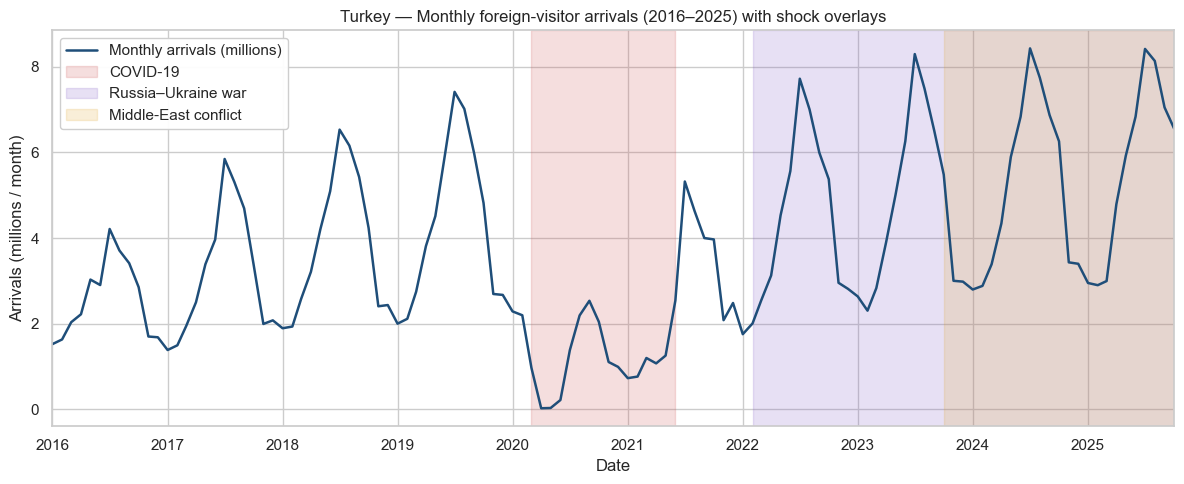

In [2]:
fig, ax = plt.subplots(figsize=(12, 5))
arrivals = df['arrivals_total'].dropna() / 1e6
ax.plot(arrivals.index, arrivals.values, color='#1f4e79', lw=1.8, label='Monthly arrivals (millions)')

shocks = [
    ('covid',      '#cc4c4c', 'COVID-19'),
    ('russia_war', '#7e57c2', 'Russia–Ukraine war'),
    ('mideast',    '#e0a32a', 'Middle-East conflict'),
]
for flag, color, label in shocks:
    on = df.index[df[flag] == 1]
    if len(on):
        ax.axvspan(on.min(), on.max(), color=color, alpha=0.18, label=label)

ax.set_xlim(arrivals.index.min(), arrivals.index.max())
ax.set_xlabel('Date')
ax.set_ylabel('Arrivals (millions / month)')
ax.set_title('Turkey — Monthly foreign-visitor arrivals (2016–2025) with shock overlays')
ax.legend(loc='upper left', framealpha=0.95)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
fig.savefig(FIG_DIR / '01_arrivals_with_shocks.png', dpi=150)
plt.show()

## 2. Nominal vs. real EUR/TRY (2010–2025)

Two series on the same time axis: **nominal EUR/TRY** (left-axis units: TRY per EUR) and **real EUR/TRY** indexed to 2015 = 100 (right-axis, dimensionless). The gap between the two captures the cumulative inflation differential between Türkiye and Germany. When real EUR/TRY drifts above 100, TRY has become *cheaper for Eurozone tourists in purchasing-power terms* — the key intuition for the demand model.

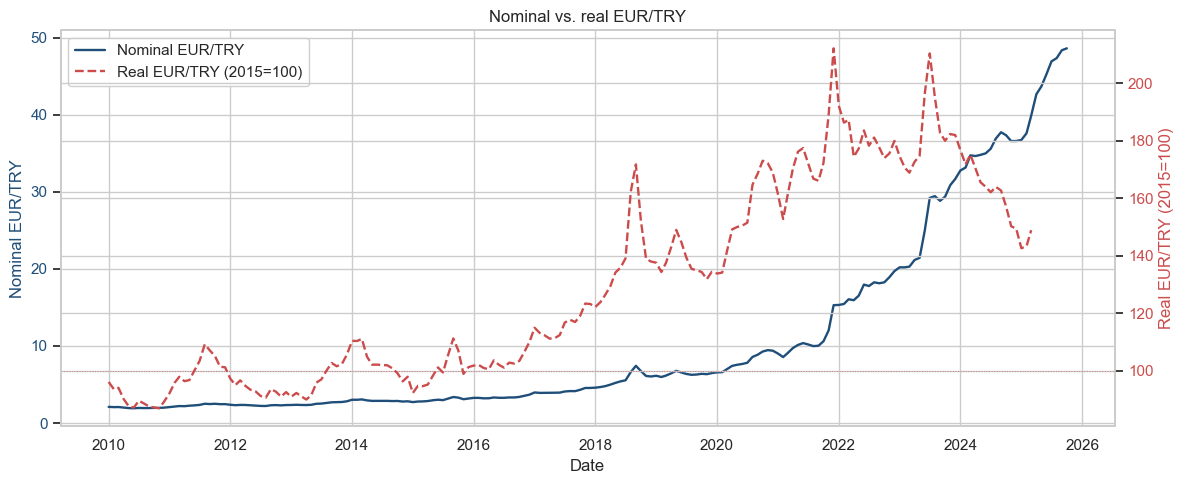

In [3]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

nom = df['EUR_TRY'].dropna()
real = df['real_EUR_TRY'].dropna()
ax1.plot(nom.index, nom.values, color='#1f4e79', lw=1.7, label='Nominal EUR/TRY')
ax2.plot(real.index, real.values, color='#cc4c4c', lw=1.7, ls='--', label='Real EUR/TRY (2015=100)')
ax2.axhline(100, color='#cc4c4c', lw=0.7, ls=':', alpha=0.6)

ax1.set_xlabel('Date')
ax1.set_ylabel('Nominal EUR/TRY', color='#1f4e79')
ax2.set_ylabel('Real EUR/TRY (2015=100)', color='#cc4c4c')
ax1.tick_params(axis='y', labelcolor='#1f4e79')
ax2.tick_params(axis='y', labelcolor='#cc4c4c')
ax1.set_title('Nominal vs. real EUR/TRY')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.95)
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
fig.savefig(FIG_DIR / '02_eur_try_nominal_vs_real.png', dpi=150)
plt.show()

## 3. Real EUR/TRY vs. arrivals, 2016–2025 (COVID highlighted)

Cross-sectional view of the same period as plot 1, plotting each month as one dot: real EUR/TRY on the x-axis (cheaper TRY → right), arrivals on the y-axis. COVID months are coloured red. The expected pattern is a positive slope on the non-COVID points (cheaper real TRY → more arrivals) with the COVID cluster sitting far below the curve — a temporary demand collapse unrelated to FX.

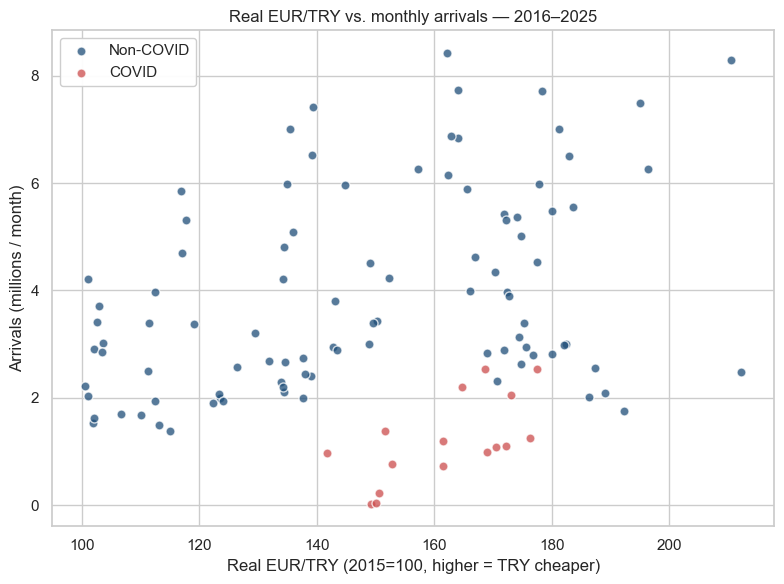

In [4]:
sub = df.loc['2016':'2025', ['real_EUR_TRY', 'arrivals_total', 'covid']].dropna(
    subset=['real_EUR_TRY', 'arrivals_total']
)
fig, ax = plt.subplots(figsize=(8, 6))
for flag_val, color, label in [(0, '#1f4e79', 'Non-COVID'), (1, '#cc4c4c', 'COVID')]:
    m = sub['covid'] == flag_val
    ax.scatter(sub.loc[m, 'real_EUR_TRY'], sub.loc[m, 'arrivals_total'] / 1e6,
               color=color, alpha=0.75, s=42, edgecolor='white', label=label)

ax.set_xlabel('Real EUR/TRY (2015=100, higher = TRY cheaper)')
ax.set_ylabel('Arrivals (millions / month)')
ax.set_title('Real EUR/TRY vs. monthly arrivals — 2016–2025')
ax.legend(loc='upper left', framealpha=0.95)
fig.tight_layout()
fig.savefig(FIG_DIR / '03_real_eur_vs_arrivals_scatter.png', dpi=150)
plt.show()

## 4. Google-Trends (Germany) vs. realised arrivals

Search-intent leading indicator: the Trends index for *Türkei Urlaub* (Germany) on the left axis, monthly Turkish arrivals on the right axis. If German tourists plan trips two-to-three months ahead, search peaks should sit slightly to the left of arrival peaks. Use this plot to eyeball both contemporaneous and lagged comovement ahead of formal lag analysis in the modelling phase.

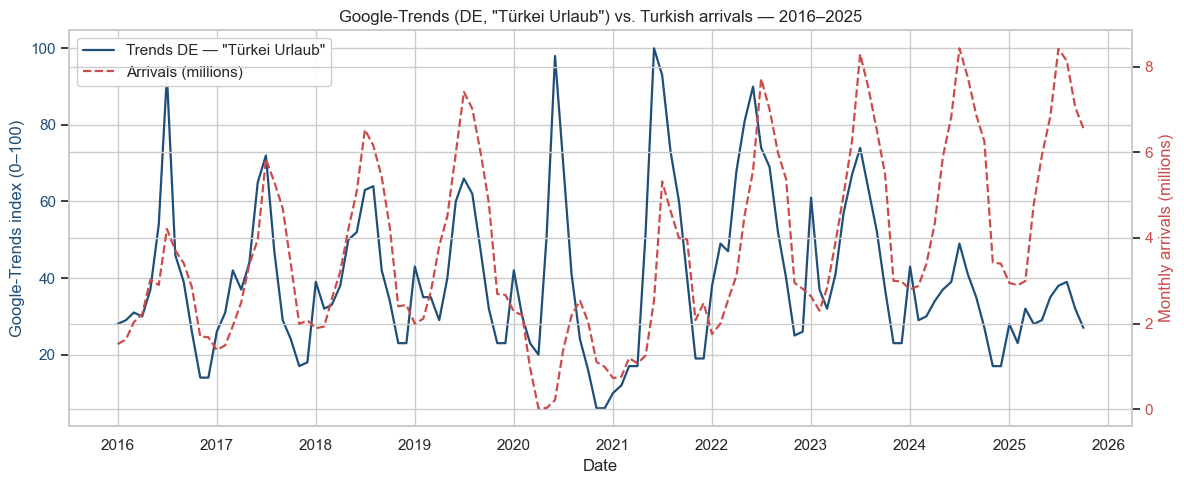

In [5]:
sub = df.loc['2016':'2025', ['trends_DE_Türkei_Urlaub', 'arrivals_total']].dropna()
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(sub.index, sub['trends_DE_Türkei_Urlaub'],
         color='#1f4e79', lw=1.6, label='Trends DE — "Türkei Urlaub"')
ax2.plot(sub.index, sub['arrivals_total'] / 1e6,
         color='#cc4c4c', lw=1.6, ls='--', label='Arrivals (millions)')

ax1.set_xlabel('Date')
ax1.set_ylabel('Google-Trends index (0–100)', color='#1f4e79')
ax2.set_ylabel('Monthly arrivals (millions)', color='#cc4c4c')
ax1.tick_params(axis='y', labelcolor='#1f4e79')
ax2.tick_params(axis='y', labelcolor='#cc4c4c')
ax1.set_title('Google-Trends (DE, "Türkei Urlaub") vs. Turkish arrivals — 2016–2025')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.95)
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
fig.savefig(FIG_DIR / '04_trends_de_vs_arrivals.png', dpi=150)
plt.show()

## 5. Correlation overview

Pearson correlations across arrivals, all four real-FX series, and the DE/GB Trends columns. Pairwise computation drops missing values per pair — important because the series have very different coverage windows (real_RUB_TRY ends 2022-03, arrivals starts 2016-01, real_EUR/GBP end 2025-03). The heatmap is the starting point for deciding which regressors belong in the demand model.

_Note: no US Trends column exists in `master_monthly.csv` (the original fetch did not query the US geo). Add it to `data_fetch.py` if a US Trends regressor is wanted._

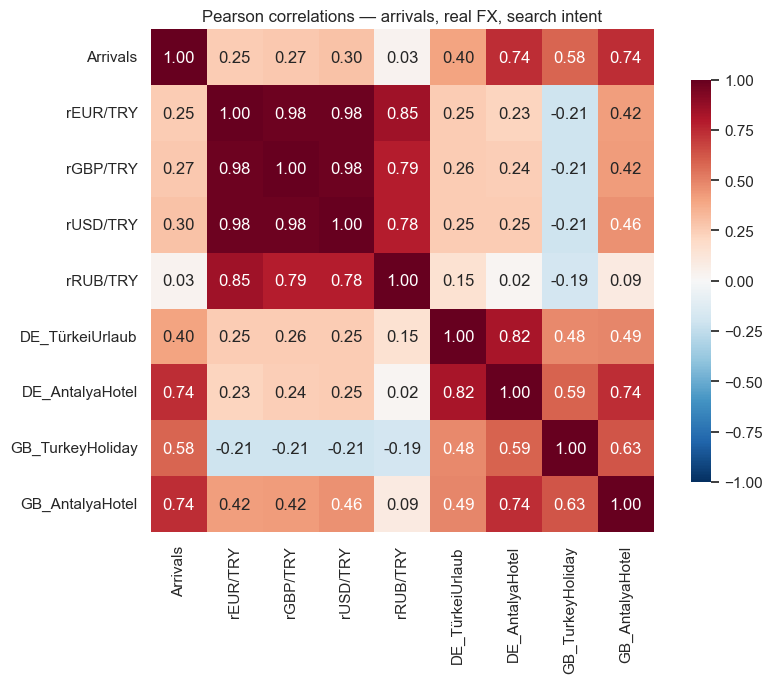

In [6]:
cols = [
    'arrivals_total',
    'real_EUR_TRY', 'real_GBP_TRY', 'real_USD_TRY', 'real_RUB_TRY',
    'trends_DE_Türkei_Urlaub', 'trends_DE_Antalya_Hotel',
    'trends_GB_Turkey_holiday', 'trends_GB_Antalya_hotel',
]
corr = df[cols].corr(method='pearson')

short = {
    'arrivals_total':         'Arrivals',
    'real_EUR_TRY':           'rEUR/TRY',
    'real_GBP_TRY':           'rGBP/TRY',
    'real_USD_TRY':           'rUSD/TRY',
    'real_RUB_TRY':           'rRUB/TRY',
    'trends_DE_Türkei_Urlaub':  'DE_TürkeiUrlaub',
    'trends_DE_Antalya_Hotel':  'DE_AntalyaHotel',
    'trends_GB_Turkey_holiday': 'GB_TurkeyHoliday',
    'trends_GB_Antalya_hotel':  'GB_AntalyaHotel',
}
corr = corr.rename(index=short, columns=short)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            center=0, square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Pearson correlations — arrivals, real FX, search intent')
fig.tight_layout()
fig.savefig(FIG_DIR / '05_correlation_heatmap.png', dpi=150)
plt.show()

## 6. Top-8 source-country market shares (2010–2025)

Reads `data/raw/tuik_country_year.csv` (annual TÜİK arrivals by country of origin), computes each country's share of total foreign arrivals per year, keeps the eight countries with the largest average share over the window, and plots a stacked area of those shares from 2010 through the latest available year. Saved as `outputs/figures/06_country_shares.png`. If the raw file is not present (e.g. TÜİK Excel not downloaded yet), the cell prints a skip message instead of erroring.

In [7]:
cy_path = ROOT / 'data' / 'raw' / 'tuik_country_year.csv'
if cy_path.exists():
    cy = pd.read_csv(cy_path)
    yearly_totals = cy.groupby('year')['arrivals'].sum()
    cy['share'] = cy.apply(lambda r: r['arrivals'] / yearly_totals[r['year']], axis=1)

    top8 = (cy.groupby('country')['share'].mean()
              .sort_values(ascending=False).head(8).index.tolist())
    pivot = (cy[cy['country'].isin(top8)]
               .pivot(index='year', columns='country', values='share')
               .reindex(columns=top8).fillna(0)
               .loc[2010:])

    fig, ax = plt.subplots(figsize=(12, 5.5))
    ax.stackplot(pivot.index, pivot.T.values,
                 labels=pivot.columns, alpha=0.90)
    ax.set_xlim(pivot.index.min(), pivot.index.max())
    ax.set_ylim(0, pivot.sum(axis=1).max() * 1.05)
    ax.set_xlabel('Year')
    ax.set_ylabel('Share of total foreign arrivals')
    ax.set_title('Turkey — Top 8 source-country market shares, 2010–2025')
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.00), framealpha=0.95)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    fig.tight_layout()
    fig.savefig(FIG_DIR / '06_country_shares.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('tuik_country_year.csv not present, skipping (rerun data_fetch after '
          'placing data/raw/tuik_turizm.xlsx)')

tuik_country_year.csv not present, skipping (rerun data_fetch after placing data/raw/tuik_turizm.xlsx)


## Next

All figures saved under `outputs/figures/`. From here, the demand-model phase can proceed: build per-source-country regressions (or a panel) with arrivals as the dependent variable and real FX + Trends + shock flags as regressors.